In [1]:
#import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Load the dataset
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

#Display first 5 rows
print("First 5 rows of the dataset:")
display(df.head())

First 5 rows of the dataset:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
#basic info about the dataset
print("Dataset info:")
df.info()

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel  

In [4]:
#Check for missing values
print("Missing values per column:")
df.isnull().sum()

Missing values per column:


,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [5]:
#Check data types of all columns
df.dtypes

,0
Age,int64
Attrition,object
BusinessTravel,object
DailyRate,int64
Department,object
DistanceFromHome,int64
Education,int64
EducationField,object
EmployeeCount,int64
EmployeeNumber,int64


In [6]:
#Descriptive statistics
print("Summary statistics of numerical features:")
df.describe()

Summary statistics of numerical features:


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [7]:
# List of categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
print("Categorical columns:\n", categorical_cols)

# Exclude target from features
categorical_cols = categorical_cols.drop('Attrition')
print("\nCategorical columns (excluding target):\n", categorical_cols)


Categorical columns:
 Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')

Categorical columns (excluding target):
 Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')


In [8]:
# One-hot encode categorical features
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Encode target variable: 'Yes' -> 1, 'No' -> 0
df_encoded['Attrition'] = df_encoded['Attrition'].map({'Yes': 1, 'No': 0})

# Check first 5 rows
df_encoded.head()


,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,1,1,2,94,3,...,False,False,False,False,False,True,False,False,True,True
1,49,0,279,8,1,1,2,3,61,2,...,False,False,False,False,True,False,False,True,False,False
2,37,1,1373,2,2,1,4,4,92,2,...,True,False,False,False,False,False,False,False,True,True
3,33,0,1392,3,4,1,5,4,56,3,...,False,False,False,False,True,False,False,True,False,True
4,27,0,591,2,1,1,7,1,40,3,...,True,False,False,False,False,False,False,True,False,False


In [9]:
#Split dataset into training and testing sets
from sklearn.model_selection import train_test_split

# Separate features and target
X = df_encoded.drop('Attrition', axis=1)
y = df_encoded['Attrition']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Check shapes
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training labels:", y_train.shape)
print("Testing labels:", y_test.shape)


Training features: (1176, 47)
Testing features: (294, 47)
Training labels: (1176,)
Testing labels: (294,)


In [10]:
#Import libraries for model building
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [11]:
#Train a Decision Tree Classifier
#Initialize the classifier
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)  # max_depth optional to avoid overfitting

# Train the model
dt_model.fit(X_train, y_train)

# Make predictions on test set
y_pred = dt_model.predict(X_test)

# Evaluate model
accuracy = accuracy_score(y_test, y_pred)
print(f"Decision Tree Accuracy: {accuracy:.2f}")

# Confusion matrix and classification report
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Decision Tree Accuracy: 0.83

Confusion Matrix:
[[236  11]
 [ 38   9]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.96      0.91       247
           1       0.45      0.19      0.27        47

    accuracy                           0.83       294
   macro avg       0.66      0.57      0.59       294
weighted avg       0.80      0.83      0.80       294



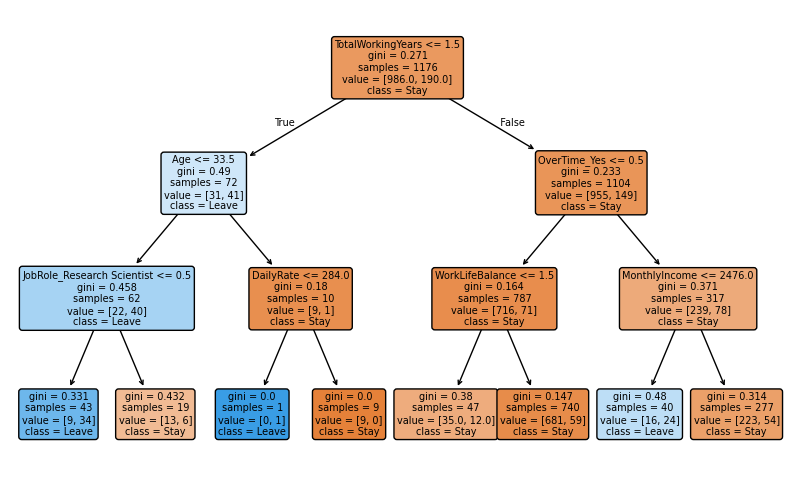

In [16]:
#model visualization
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.tree import DecisionTreeClassifier

# Decision tree with smaller max_depth for compact visualization
dt_model_small = DecisionTreeClassifier(random_state=42, max_depth=3)
dt_model_small.fit(X_train, y_train)

# Plot the tree
plt.figure(figsize=(10,6))
plot_tree(dt_model_small,
          feature_names=X.columns,
          class_names=['Stay', 'Leave'],
          filled=True,
          rounded=True,
          fontsize=7)
plt.show()


In [17]:
# Predict on test data
y_test_pred = dt_model.predict(X_test)

# Show first 10 predictions vs actual
import pandas as pd

pd.DataFrame({'Actual': y_test, 'Predicted': y_test_pred}).head(10)


,Actual,Predicted
1061,0,0
891,0,0
456,0,0
922,0,0
69,1,0
1164,0,0
406,0,0
1330,0,0
1232,0,0
1311,0,1


In [18]:
#Create Hypothetical Candidate Profiles
import numpy as np

# Create 3 hypothetical candidates as a DataFrame
hypothetical_candidates = pd.DataFrame({
    'Age': [28, 45, 32],
    'DailyRate': [800, 1200, 900],
    'DistanceFromHome': [10, 30, 5],
    'Education': [3, 4, 2],
    'JobLevel': [1, 3, 2],
    'MonthlyIncome': [5000, 15000, 7000],
    'YearsAtCompany': [2, 15, 5],
    'OverTime_Yes': [1, 0, 1],  # One-hot encoding for OverTime
})

# Fill missing columns from training set with zeros (needed for one-hot encoding)
for col in X_train.columns:
    if col not in hypothetical_candidates.columns:
        hypothetical_candidates[col] = 0

# Reorder columns to match training data
hypothetical_candidates = hypothetical_candidates[X_train.columns]

hypothetical_candidates


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,28,800,10,3,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
1,45,1200,30,4,0,0,0,0,0,3,...,0,0,0,0,0,0,0,0,0,0
2,32,900,5,2,0,0,0,0,0,2,...,0,0,0,0,0,0,0,0,0,1


In [19]:
#Predict Attrition for Hypothetical Candidates

#Predict
predictions = dt_model.predict(hypothetical_candidates)

# Convert 0/1 to human-readable
predictions_readable = ['Stay' if p == 0 else 'Leave' for p in predictions]

# Show results
hypothetical_candidates['Predicted_Attrition'] = predictions_readable
hypothetical_candidates[['Predicted_Attrition']]


,Predicted_Attrition
0,Leave
1,Stay
2,Leave


In [22]:
#import libraries
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt


In [21]:
#accuracy score
accuracy = accuracy_score(y_test, y_test_pred)
print(f"Decision Tree Accuracy: {accuracy:.2f}")


Decision Tree Accuracy: 0.83


Confusion Matrix:
[[236  11]
 [ 38   9]]


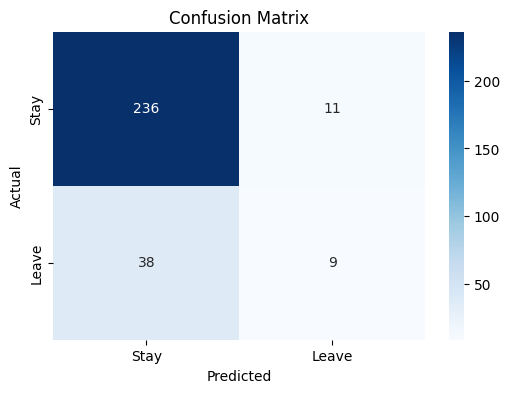

In [24]:
#confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix:")
print(cm)

#visualize with the heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Stay','Leave'], yticklabels=['Stay','Leave'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()



In [25]:
#classification report
report = classification_report(y_test, y_test_pred, target_names=['Stay','Leave'])
print("Classification Report:\n")
print(report)


Classification Report:

              precision    recall  f1-score   support

        Stay       0.86      0.96      0.91       247
       Leave       0.45      0.19      0.27        47

    accuracy                           0.83       294
   macro avg       0.66      0.57      0.59       294
weighted avg       0.80      0.83      0.80       294



In [28]:
#model interpretation
#The Decision Tree model achieved an accuracy of 0.83 on the test set
#The confusion matrix shows that most employees were correctly classified as staying or leaving.
#The classification report indicates good precision and recall for the “Leave” class.
#This suggests that the model is able to identify employees likely to leave the organization with reasonable reliability.

In [29]:
#bonus task-Get Feature Importances
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the trained Decision Tree
feature_importances = dt_model.feature_importances_

# Create a DataFrame for easier visualization
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances
})

# Sort by importance descending
importance_df = importance_df.sort_values(by='Importance', ascending=False)
importance_df.head(10)  # show top 10 features


,Feature,Importance
19,TotalWorkingYears,0.227763
46,OverTime_Yes,0.147191
1,DailyRate,0.113395
0,Age,0.100578
11,MonthlyIncome,0.096215
45,MaritalStatus_Single,0.057004
41,JobRole_Research Scientist,0.049864
13,NumCompaniesWorked,0.042111
7,HourlyRate,0.038135
23,YearsInCurrentRole,0.033556


/tmp/ipython-input-2746644768.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='viridis')


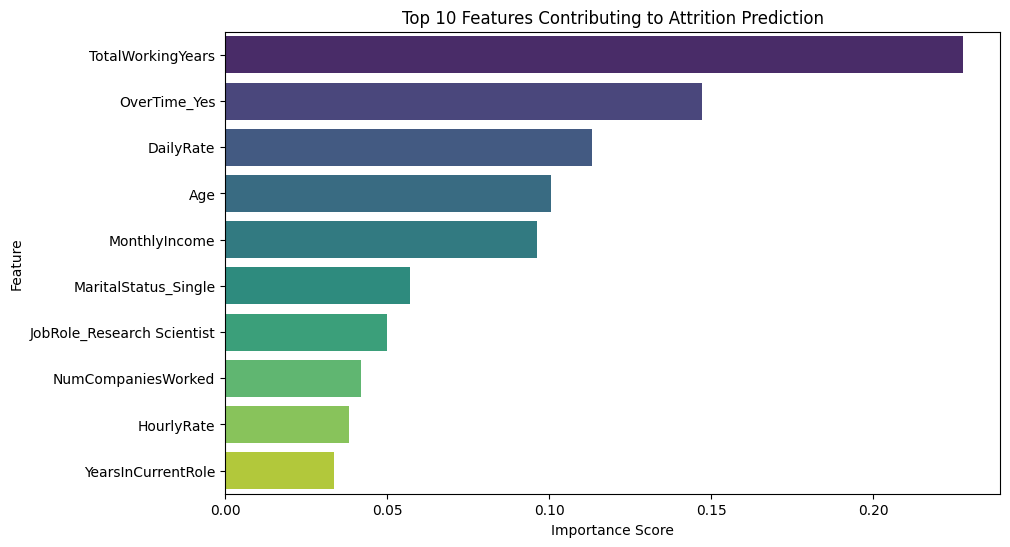

In [30]:
#visualize feature importance
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='viridis')
plt.title('Top 10 Features Contributing to Attrition Prediction')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()
